In [1]:
#Load modules
import pandas as pd
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from numpy import mean
from numpy import absolute
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
import numpy as np


In [2]:
#pre-process the data
df = pd.read_csv("insurance.csv")

#select features
y= df['death']
X = df.drop('death',axis=1) #Select features
X = pd.get_dummies(X, drop_first=True) 

#Normalize the data
columns = X.columns #create index with column names (needed for last step)
scaler = MinMaxScaler() #initiate the scaler
X = scaler.fit_transform(X) #scale the data
X = pd.DataFrame(X,columns=columns) #turn back into a dataframe

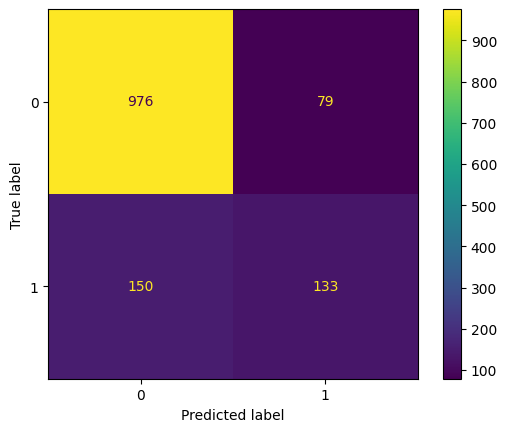

Accuracy: 0.8288490284005979


In [3]:
#Make the prediction
rf = RandomForestClassifier(n_estimators=100, random_state=69)

y_pred = cross_val_predict(rf, X, y, cv=5) #make the predictions

cm = confusion_matrix(y, y_pred) #create the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm) #create the graph
disp.plot() #plot the graph
plt.show() #show the graph

accuracy = (cm.diagonal().sum()) / cm.sum() #calculate accuracy
print("Accuracy:",accuracy) #print accuracy


In [4]:
#Calculate Gini importance
rf = RandomForestClassifier(n_estimators=100, random_state=69) #Define the model
rf.fit(X,y) #Fit the data to the random forest model
feature_importances = rf.feature_importances_ #get the GINI importances

importance_df = pd.DataFrame({ #create a dataframe shat shows the importance for each feature
    'Feature': X.columns,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False) #sort the data from high to low

print(importance_df) #print the result

            Feature  Importance
1               bmi    0.391470
3           charges    0.271332
0               age    0.167591
2          children    0.061690
4          sex_male    0.030782
5        smoker_yes    0.020738
7  region_southeast    0.020283
6  region_northwest    0.019470
8  region_southwest    0.016644


In [ ]:
#Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

#Define possible hyperparameters
n_estimators = np.arange(start=10, stop=250, step=10) #number of trees, it will try 10, 20, 30 etc
max_depth = np.arange(start=10,stop=250,step=10)
min_samples_split = np.arange(start=10,stop=30,step=1)
max_features = [None,'sqrt','log2']

#Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'max_features': max_features}

# search across 100 different combinations, and use all available cores
rf_random = RandomizedSearchCV(estimator = regressor, 
                               param_distributions = random_grid, 
                               n_iter = 100, #number of combination in the grid to try
                               cv = 5,#number of folds
                               random_state=69) #set random seed
rf_random.fit(X,y)# Fit the random search model

rf_random.best_params_ #reveal the best hyperparameters

{'n_estimators': 120,
 'min_samples_split': 25,
 'max_features': None,
 'max_depth': 190}

In [ ]:
#Run the optimal model
regressor = RandomForestRegressor(n_estimators=120,
                                  min_samples_split=25,
                                   max_features=None,
                                    max_depth=190,
                                      random_state=69) #create a forest with 100 trees
RFscores = cross_val_score(regressor, X, y, cv=5,
                           scoring='neg_mean_absolute_error')
MAE = mean(absolute(RFscores))
print ('the MAE is: %.2f' % MAE)

the MAE is: 2588.83


In [4]:
#Exercise 2
#pre-process the data
df = pd.read_csv("insurance.csv")

#select features
y= df['death']
X = df.drop('death',axis=1) #Select features
X = pd.get_dummies(X, drop_first=True) 

#Normalize the data
columns = X.columns #create index with column names (needed for last step)
scaler = MinMaxScaler() #initiate the scaler
X = scaler.fit_transform(X) #scale the data
X = pd.DataFrame(X,columns=columns) #turn back into a dataframe

In [5]:
rf = RandomForestClassifier(n_estimators=100, random_state=69) #Define the model
#Define possible hyperparameters
n_estimators = np.arange(start=10, stop=250, step=10) #number of trees, it will try 10, 20, 30 etc
max_depth = np.arange(start=10,stop=250,step=10)
min_samples_split = np.arange(start=10,stop=30,step=1)
max_features = [None,'sqrt','log2']

#Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'max_features': max_features}

# search across 100 different combinations, and use all available cores
rf_random = RandomizedSearchCV(estimator = rf, 
                               param_distributions = random_grid, 
                               n_iter = 100, #number of combination in the grid to try
                               cv = 5,#number of folds
                               random_state=69) #set random seed
rf_random.fit(X,y)# Fit the random search model

rf_random.best_params_ #reveal the best hyperparameters

{'n_estimators': 180,
 'min_samples_split': 21,
 'max_features': 'sqrt',
 'max_depth': 10}

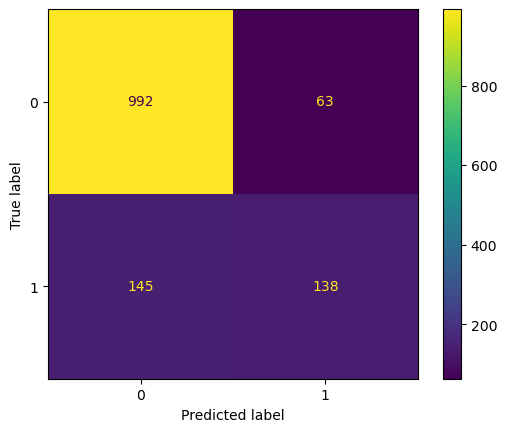

Accuracy: 0.8445440956651719


In [6]:
#Create optimal prediction
rf = RandomForestClassifier(n_estimators=180, 
                            min_samples_split=21,
                            max_features='sqrt',
                            max_depth=10,
                            random_state=69)

y_pred = cross_val_predict(rf, X, y, cv=5) #make the predictions

cm = confusion_matrix(y, y_pred) #create the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm) #create the graph
disp.plot() #plot the graph
plt.show() #show the graph

accuracy = (cm.diagonal().sum()) / cm.sum() #calculate accuracy
print("Accuracy:",accuracy) #print accuracy
